# Taller 04 — Clustering con K-means
**Inteligencia Artificial – ELP 8012 – Universidad del Norte**
**Programa de Ingeniería de Sistemas**
**Profesor: Eduardo Zurek, Ph.D.**

**Integrantes del grupo:**
- Nombre 1 (código)
- Nombre 2 (código)
- Nombre 3 (código)

## Objetivo

Diseñar e implementar un algoritmo de *clustering* K-means sobre un conjunto de datos sintéticos
bidimensionales con seis (6) grupos gaussianos isotrópicos de distinta densidad (desviación estándar),
donde dos de los grupos se superponen parcialmente, y al que se le agregan *outliers* uniformemente
distribuidos. Posteriormente se remueven los *outliers* y se aplica K-means explorando entre 2 y 12
clústeres, determinando el número óptimo de grupos mediante tres criterios: **Silhouette**, **método
del codo** y un **método basado en las etiquetas verdaderas (ground truth)**.

## Contenido

1. Configuración e importación de librerías.
2. Marco teórico breve: K-means y condiciones para que funcione bien.
3. Generación de los datos sintéticos.
4. Visualización de los datos originales (con outliers).
5. Remoción de outliers.
6. Verificación de las condiciones de K-means sobre los datos limpios (escalamiento, esfericidad).
7. Exploración de K-means para *k* = 2..12.
8. Determinación del número óptimo de clústeres (Silhouette, Codo, Ground Truth).
9. Verificación adicional con ground truth (Accuracy/F1, matriz de confusión).
10. Resultado final y conclusiones.


## 1. Configuración e importación de librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score,
    pairwise_distances,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Marco teórico breve

### 2.1 ¿Qué es clustering?

El *clustering* (agrupamiento) es una técnica de **aprendizaje no supervisado** que agrupa datos
similares en categorías sin usar etiquetas previas. Se usa, por ejemplo, en segmentación de clientes,
agrupación de imágenes o detección de patrones en datos biomédicos. Existen dos grandes familias:

- **Particional** (como K-means): divide el conjunto de datos en *K* grupos disjuntos.
- **Jerárquico**: construye un árbol de agrupamientos anidados (aglomerativo o divisivo).

### 2.2 El algoritmo K-means

K-means busca *K* centroides que minimicen la suma de distancias al cuadrado entre cada punto y el
centroide de su clúster (inercia o WCSS). De forma iterativa:

1. Se inicializan *K* centroides (aleatoriamente o con `k-means++`).
2. **Asignación**: cada punto se asigna al centroide más cercano.
3. **Actualización**: cada centroide se recalcula como el promedio de los puntos asignados a él.
4. Se repiten los pasos 2 y 3 hasta que las asignaciones dejan de cambiar (o se alcanza un máximo de
   iteraciones).

### 2.3 Condiciones para que K-means funcione bien

Para que K-means produzca agrupamientos razonables, los datos deberían cumplir aproximadamente:

| Condición | Problema si no se cumple | Cómo se verifica en este taller |
|---|---|---|
| **Clústeres esféricos y de tamaño similar** | Mal agrupamiento si los clústeres tienen formas irregulares | Varianza de distancias al centroide y matrices de covarianza (Sección 6) |
| **Variables en escalas comparables** | Una variable con rango mucho mayor domina la distancia euclidiana | Comparación con/sin `StandardScaler` (Sección 6) |
| **Pocos o ningún outlier** | Un solo outlier puede desplazar un centroide | Detección y remoción con Local Outlier Factor (Sección 5) |
| **Número correcto de clústeres (K)** | K muy chico mezcla grupos distintos; K muy grande fragmenta un mismo grupo | Silhouette, método del codo y ground truth (Secciones 7-8) |

En nuestro caso los datos se generan **isotrópicos** (misma varianza en `x` e `y`), por lo que la
condición de esfericidad se cumple por diseño; aun así, la verificamos empíricamente sobre los datos
ya agrupados.


## 3. Generación de los datos sintéticos

Se generan **6 grupos** gaussianos isotrópicos (misma varianza en `x` y en `y`), todos con el **mismo
número de puntos** pero con **diferentes desviaciones estándar** (es decir, diferente densidad).

Los centros y desviaciones se eligieron para que:
- Todos los puntos, al graficarlos, queden contenidos en el rango **[-10, 10]** en ambos ejes (se aplica
  además un *clip* de seguridad).
- **Dos de los grupos** (`G4` y `G5`) estén cerca entre sí y se superpongan parcialmente.

Finalmente se agregan **outliers** que siguen una distribución **uniforme** entre -10 y 10 en ambos ejes.


In [2]:

def generar_datos_sinteticos(n_por_grupo=150, n_outliers=60, random_state=RANDOM_STATE):
    # Genera 6 clusters gaussianos isotropicos de distinta densidad, dos de ellos
    # parcialmente superpuestos, contenidos en [-10, 10] x [-10, 10], mas outliers uniformes.
    #
    # Devuelve:
    #   X          : array (N, 2) con todos los puntos (clusters + outliers)
    #   y_true     : array (N,) con la etiqueta verdadera de cluster (0..5) o -1 si es outlier
    #   is_outlier : array booleano (N,) True si el punto es outlier
    rng = np.random.default_rng(random_state)

    # Centro (mu_x, mu_y) y desviacion estandar (misma en x e y -> isotropica) de cada grupo.
    # G4 y G5 estan cerca entre si (superposicion parcial).
    centros = np.array([
        [-6.0,  6.0],   # G0
        [-6.0, -6.0],   # G1
        [ 6.0,  6.0],   # G2
        [ 6.0, -6.0],   # G3
        [ 0.0,  0.5],   # G4  -> cerca de G5
        [ 1.6,  1.4],   # G5  -> cerca de G4 (superposicion parcial)
    ])
    sigmas = np.array([0.35, 0.70, 0.50, 0.90, 0.60, 1.00])  # diferentes densidades

    n_grupos = centros.shape[0]
    X_list, y_list = [], []

    for k in range(n_grupos):
        puntos = rng.normal(loc=centros[k], scale=sigmas[k], size=(n_por_grupo, 2))
        X_list.append(puntos)
        y_list.append(np.full(n_por_grupo, k))

    X_clusters = np.vstack(X_list)
    y_clusters = np.concatenate(y_list)

    # Outliers: distribucion uniforme en [-10, 10] x [-10, 10]
    X_outliers = rng.uniform(low=-10, high=10, size=(n_outliers, 2))
    y_outliers = np.full(n_outliers, -1)

    X = np.vstack([X_clusters, X_outliers])
    y_true = np.concatenate([y_clusters, y_outliers])
    is_outlier = y_true == -1

    # Aseguramos que TODO quede estrictamente dentro de [-10, 10]
    X = np.clip(X, -10, 10)

    # Mezclamos el orden para que no queden agrupados por bloques
    idx = rng.permutation(len(X))
    return X[idx], y_true[idx], is_outlier[idx]


X, y_true, is_outlier_true = generar_datos_sinteticos(n_por_grupo=150, n_outliers=60)

print(f"Total de puntos            : {len(X)}")
print(f"Puntos por grupo (c/u)     : 150  (6 grupos = {6*150} puntos)")
print(f"Outliers                   : {is_outlier_true.sum()}")
print(f"Rango eje X                : [{X[:,0].min():.2f}, {X[:,0].max():.2f}]")
print(f"Rango eje Y                : [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")


Total de puntos            : 960
Puntos por grupo (c/u)     : 150  (6 grupos = 900 puntos)
Outliers                   : 60
Rango eje X                : [-9.76, 9.98]
Rango eje Y                : [-9.78, 9.81]


## 4. Visualización de los datos originales (con outliers)

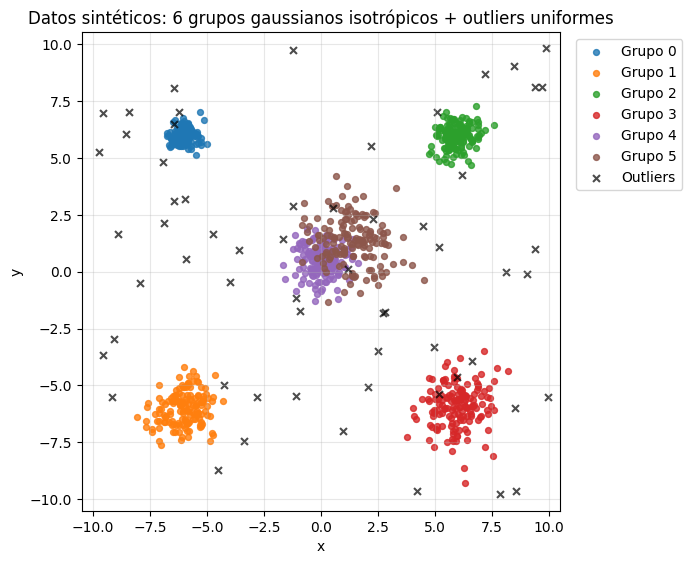

In [3]:

fig, ax = plt.subplots(figsize=(7, 7))

colores = cm.tab10(np.linspace(0, 1, 10))

for k in range(6):
    mask = y_true == k
    ax.scatter(X[mask, 0], X[mask, 1], s=18, color=colores[k], alpha=0.8, label=f"Grupo {k}")

ax.scatter(X[is_outlier_true, 0], X[is_outlier_true, 1],
           s=25, color="black", marker="x", alpha=0.7, label="Outliers")

ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.set_title("Datos sintéticos: 6 grupos gaussianos isotrópicos + outliers uniformes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


Se observa que:
- Los grupos `G0`, `G1`, `G2` y `G3` están bien separados y ubicados cerca de las esquinas del cuadrado
  `[-10, 10] x [-10, 10]`.
- Los grupos `G4` y `G5` están cerca del centro y **se superponen parcialmente**, tal como lo pide el
  enunciado.
- Las densidades (desviaciones estándar) son distintas entre grupos: algunos puntos están muy
  concentrados (p. ej. `G0`) y otros mucho más dispersos (p. ej. `G5`).
- Los outliers (marcados con `x` negra) se distribuyen de manera uniforme en todo el plano.

## 5. Remoción de outliers

Para remover los outliers **sin usar las etiquetas verdaderas** (como ocurriría en un escenario real),
se utiliza un método de detección de anomalías basado en densidad local: **Local Outlier Factor (LOF)**.

LOF compara la densidad local de cada punto con la densidad local de sus vecinos: un punto que está en
una región mucho menos densa que sus vecinos recibe un puntaje de anomalía alto y se marca como outlier.
Es un método adecuado aquí porque los outliers uniformes tienden a caer en zonas de baja densidad
comparadas con los 6 clústeres gaussianos.

Después de remover los outliers detectados, comparamos el resultado contra la marca real de outliers
(`is_outlier_true`) únicamente a modo de **validación** del proceso (en un caso real esta comparación
no estaría disponible).


In [4]:

# Estimamos la proporcion de outliers a partir del diseño del experimento (contamination)
contamination = is_outlier_true.sum() / len(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
pred_lof = lof.fit_predict(X)          # 1 = inlier, -1 = outlier (detectado)
is_outlier_pred = pred_lof == -1

# Validacion contra la verdad conocida (solo posible porque los datos son sinteticos)
tp = np.sum(is_outlier_pred & is_outlier_true)
fp = np.sum(is_outlier_pred & ~is_outlier_true)
fn = np.sum(~is_outlier_pred & is_outlier_true)
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

print(f"Outliers detectados por LOF : {is_outlier_pred.sum()}")
print(f"Outliers reales             : {is_outlier_true.sum()}")
print(f"Precision                   : {precision:.2f}")
print(f"Recall                      : {recall:.2f}")

# Conjunto de datos SIN outliers (el que se usara para el clustering)
X_clean = X[~is_outlier_pred]
y_true_clean = y_true[~is_outlier_pred]   # solo para evaluacion posterior (ground truth)

print(f"\nPuntos originales : {len(X)}")
print(f"Puntos removidos   : {is_outlier_pred.sum()}")
print(f"Puntos restantes   : {len(X_clean)}")


Outliers detectados por LOF : 60
Outliers reales             : 60
Precision                   : 0.82
Recall                      : 0.82

Puntos originales : 960
Puntos removidos   : 60
Puntos restantes   : 900


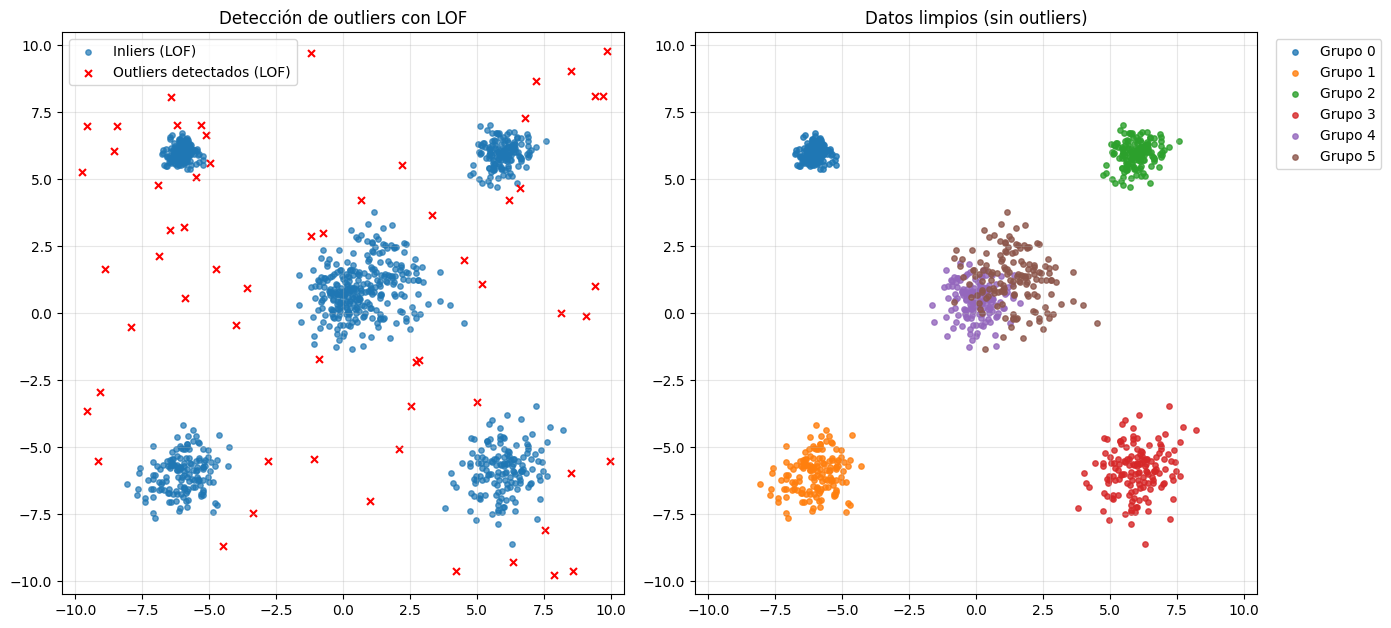

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

axes[0].scatter(X[~is_outlier_pred, 0], X[~is_outlier_pred, 1], s=15, color="tab:blue", alpha=0.7, label="Inliers (LOF)")
axes[0].scatter(X[is_outlier_pred, 0], X[is_outlier_pred, 1], s=25, color="red", marker="x", label="Outliers detectados (LOF)")
axes[0].set_title("Detección de outliers con LOF")
axes[0].legend()
axes[0].set_xlim(-10.5, 10.5); axes[0].set_ylim(-10.5, 10.5); axes[0].set_aspect("equal")

for k in range(6):
    mask = y_true_clean == k
    axes[1].scatter(X_clean[mask, 0], X_clean[mask, 1], s=15, color=colores[k], alpha=0.8, label=f"Grupo {k}")
axes[1].set_title("Datos limpios (sin outliers)")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
axes[1].set_xlim(-10.5, 10.5); axes[1].set_ylim(-10.5, 10.5); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()


## 6. Verificación de las condiciones de K-means sobre los datos limpios

Antes de explorar distintos valores de `k`, verificamos empíricamente dos de las condiciones descritas
en la Sección 2: el **escalamiento** de las variables y la **esfericidad** de los clústeres. Para esto
ajustamos un K-means preliminar con `k = 6` (el número real de grupos generados) sobre `X_clean`.


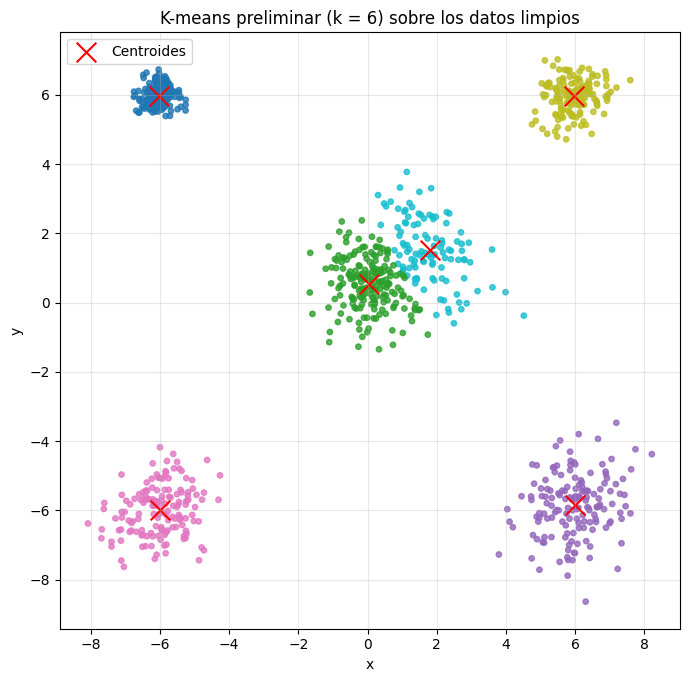

In [6]:

kmeans_demo = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10).fit(X_clean)
labels_demo = kmeans_demo.labels_
centroids_demo = kmeans_demo.cluster_centers_

fig, ax = plt.subplots(figsize=(7, 7))
scatter = ax.scatter(X_clean[:, 0], X_clean[:, 1], c=labels_demo, cmap="tab10", s=15, alpha=0.8)
ax.scatter(centroids_demo[:, 0], centroids_demo[:, 1], c="red", marker="x", s=200, label="Centroides")
ax.set_title("K-means preliminar (k = 6) sobre los datos limpios")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### 6.1 Escalamiento de los datos

K-means usa distancia euclidiana, por lo que si las variables tuvieran escalas muy distintas, la de
mayor rango dominaría el agrupamiento. En nuestro caso `x` e `y` ya están en el mismo rango
`[-10, 10]` (los datos son isotrópicos por construcción), por lo que **no es estrictamente necesario
escalar**. Aun así, aplicamos `StandardScaler` a modo de buena práctica y verificamos que el
agrupamiento resultante es equivalente.


In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print("Medias antes de escalar :", X_clean.mean(axis=0).round(3))
print("Medias despues de escalar:", X_scaled.mean(axis=0).round(3))
print("Desv. estandar antes    :", X_clean.std(axis=0).round(3))
print("Desv. estandar despues  :", X_scaled.std(axis=0).round(3))

kmeans_scaled = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
ari_scaled = adjusted_rand_score(y_true_clean, kmeans_scaled.labels_)
ari_sin_escalar = adjusted_rand_score(y_true_clean, labels_demo)

print(f"\nARI sin escalar : {ari_sin_escalar:.3f}")
print(f"ARI escalado    : {ari_scaled:.3f}")
print("\nComo x e y ya tienen rangos comparables, el escalamiento no cambia el resultado de forma"
      " apreciable. Seguimos trabajando con los datos originales (sin escalar) por simplicidad e"
      " interpretabilidad de las coordenadas.")


Medias antes de escalar : [0.223 0.272]
Medias despues de escalar: [ 0. -0.]
Desv. estandar antes    : [4.963 4.922]
Desv. estandar despues  : [1. 1.]

ARI sin escalar : 0.864
ARI escalado    : 0.861

Como x e y ya tienen rangos comparables, el escalamiento no cambia el resultado de forma apreciable. Seguimos trabajando con los datos originales (sin escalar) por simplicidad e interpretabilidad de las coordenadas.


### 6.2 Esfericidad de los clústeres

Se analiza qué tan esféricos (compactos y sin correlación entre `x` e `y`) son los clústeres
encontrados, usando dos criterios:

- **Varianza de las distancias al centroide**: valores bajos indican clústeres compactos y esféricos.
- **Matriz de covarianza dentro de cada clúster**: si es aproximadamente diagonal (poca correlación
  entre `x` e `y`), el clúster es esférico; si tiene valores grandes fuera de la diagonal, está
  alargado en alguna dirección.


In [8]:

def sphericity_variance(X, labels, centroids):
    filas = []
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        distances = pairwise_distances(cluster_points, [centroids[i]])
        variance = np.var(distances)
        filas.append({"Cluster": i, "N_puntos": len(cluster_points), "Varianza_distancias": variance})
    return pd.DataFrame(filas)

df_var = sphericity_variance(X_clean, labels_demo, centroids_demo)
df_var


,Cluster,N_puntos,Varianza_distancias
0,0,147,0.036308
1,1,193,0.218377
2,2,151,0.330396
3,3,151,0.208975
4,4,149,0.113717
5,5,109,0.344424


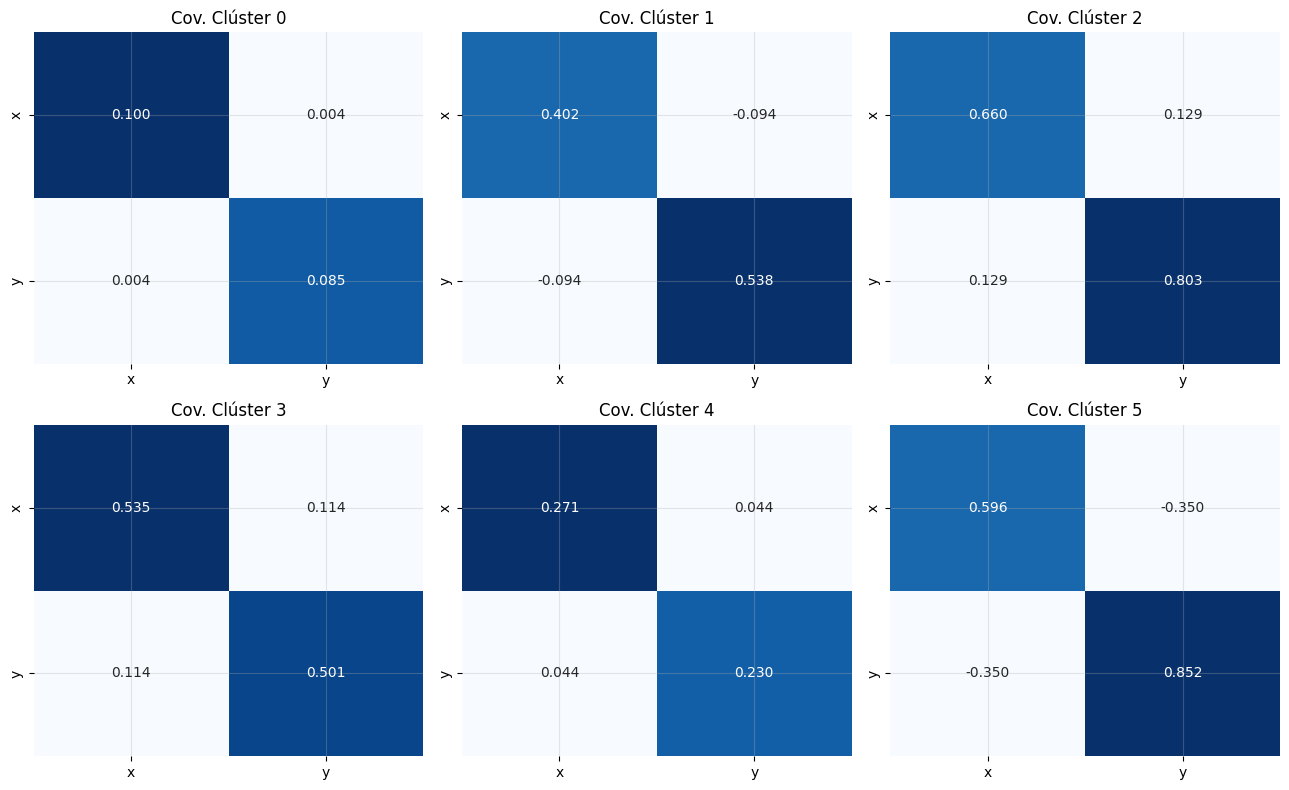

Las matrices de covarianza son aproximadamente diagonales (valores fuera de la diagonal cercanos a 0), lo que confirma que los clústeres son esféricos, tal como se diseñaron.


In [9]:

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for i in range(6):
    cluster_data = X_clean[labels_demo == i]
    cov_matrix = np.cov(cluster_data.T)
    sns.heatmap(cov_matrix, annot=True, fmt=".3f", cmap="Blues", cbar=False,
                xticklabels=["x", "y"], yticklabels=["x", "y"], ax=axes[i])
    axes[i].set_title(f"Cov. Clúster {i}")

plt.tight_layout()
plt.show()

print("Las matrices de covarianza son aproximadamente diagonales (valores fuera de la diagonal"
      " cercanos a 0), lo que confirma que los clústeres son esféricos, tal como se diseñaron.")


### 6.3 Distribución de los coeficientes de Silhouette

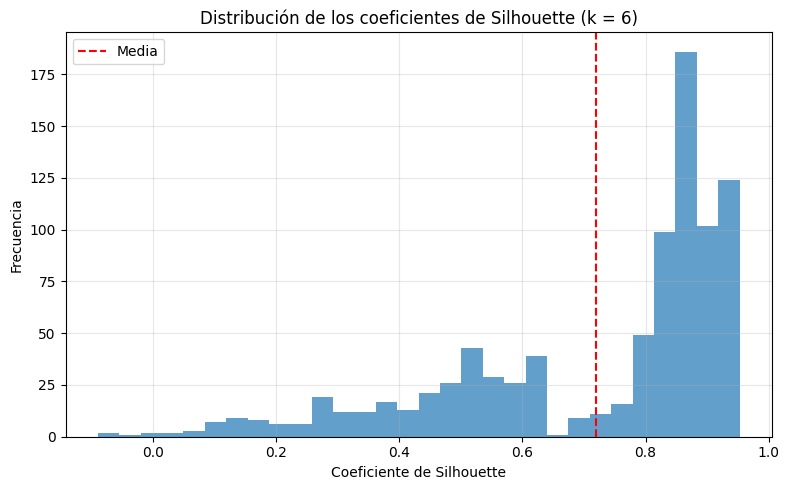

Silhouette promedio (k=6): 0.720
La mayoria de los valores estan bien por encima de 0 y cercanos a los mayores valores posibles, lo que indica clusters razonablemente compactos y bien separados. Algunos valores mas bajos (incluso levemente negativos) corresponden a los puntos de la zona de superposicion entre los grupos G4 y G5.


In [10]:

silhouette_vals_demo = silhouette_samples(X_clean, labels_demo)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(silhouette_vals_demo, bins=30, color="tab:blue", alpha=0.7)
ax.axvline(np.mean(silhouette_vals_demo), color="red", linestyle="--", label="Media")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de los coeficientes de Silhouette (k = 6)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Silhouette promedio (k=6): {silhouette_vals_demo.mean():.3f}")
print("La mayoria de los valores estan bien por encima de 0 y cercanos a los mayores valores"
      " posibles, lo que indica clusters razonablemente compactos y bien separados. Algunos valores"
      " mas bajos (incluso levemente negativos) corresponden a los puntos de la zona de superposicion"
      " entre los grupos G4 y G5.")


## 7. Exploración de K-means para *k* = 2..12

Se entrena K-means sobre los datos **sin outliers** (`X_clean`) para cada valor de `k` entre 2 y 12,
guardando en cada caso:

- **Inercia** (suma de distancias al cuadrado a los centroides) → usada para el **método del codo**.
- **Coeficiente de Silhouette promedio** → usado para el **método de Silhouette**.
- **ARI (Adjusted Rand Index)** y **NMI (Normalized Mutual Information)** frente a las etiquetas
  verdaderas → usados para el **método basado en ground truth**.


In [11]:

K_MIN, K_MAX = 2, 12
ks = list(range(K_MIN, K_MAX + 1))

inercias = []
silhouettes = []
aris = []
nmis = []
modelos = {}

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_clean)
    modelos[k] = km

    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clean, labels))
    aris.append(adjusted_rand_score(y_true_clean, labels))
    nmis.append(normalized_mutual_info_score(y_true_clean, labels))

resultados = {
    "k": ks,
    "inercia": inercias,
    "silhouette": silhouettes,
    "ari": aris,
    "nmi": nmis,
}

print(f"{'k':>3} | {'Inercia':>10} | {'Silhouette':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 52)
for i, k in enumerate(ks):
    print(f"{k:>3} | {inercias[i]:>10.1f} | {silhouettes[i]:>10.3f} | {aris[i]:>8.3f} | {nmis[i]:>8.3f}")


  k |    Inercia | Silhouette |      ARI |      NMI
----------------------------------------------------
  2 |    26499.1 |      0.463 |    0.268 |    0.499
  3 |    15653.1 |      0.568 |    0.326 |    0.636
  4 |     6440.7 |      0.715 |    0.557 |    0.798
  5 |     1093.2 |      0.830 |    0.806 |    0.909
  6 |      813.0 |      0.720 |    0.864 |    0.897
  7 |      730.9 |      0.638 |    0.808 |    0.869
  8 |      646.2 |      0.624 |    0.801 |    0.851
  9 |      586.2 |      0.536 |    0.742 |    0.825
 10 |      525.7 |      0.515 |    0.700 |    0.803
 11 |      489.5 |      0.516 |    0.681 |    0.795
 12 |      449.5 |      0.520 |    0.664 |    0.781


## 8. Determinación del número óptimo de clústeres

### 8.1 Método de Silhouette

El número óptimo de clústeres según Silhouette es aquel que **maximiza** el coeficiente de Silhouette
promedio (valores cercanos a 1 indican clústeres bien separados y compactos).


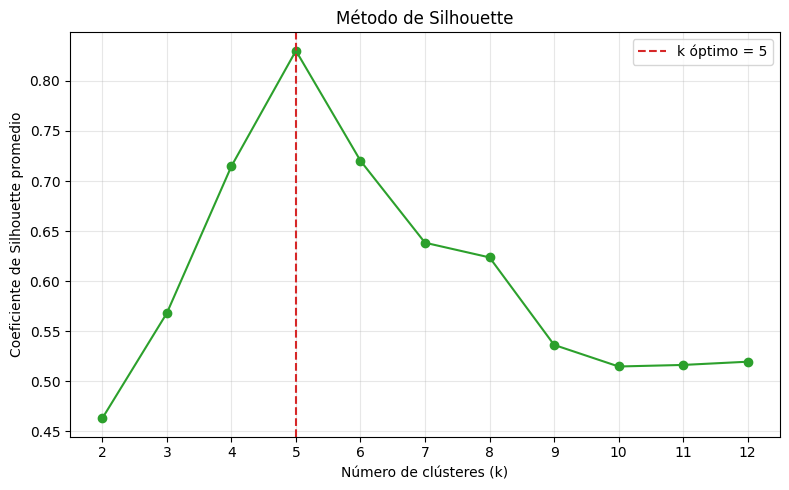

k óptimo según Silhouette: 5 (silhouette = 0.830)


In [12]:

k_optimo_silhouette = ks[int(np.argmax(silhouettes))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, silhouettes, marker="o", color="tab:green")
ax.axvline(k_optimo_silhouette, color="tab:red", linestyle="--",
           label=f"k óptimo = {k_optimo_silhouette}")
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Coeficiente de Silhouette promedio")
ax.set_title("Método de Silhouette")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()

print(f"k óptimo según Silhouette: {k_optimo_silhouette} "
      f"(silhouette = {max(silhouettes):.3f})")


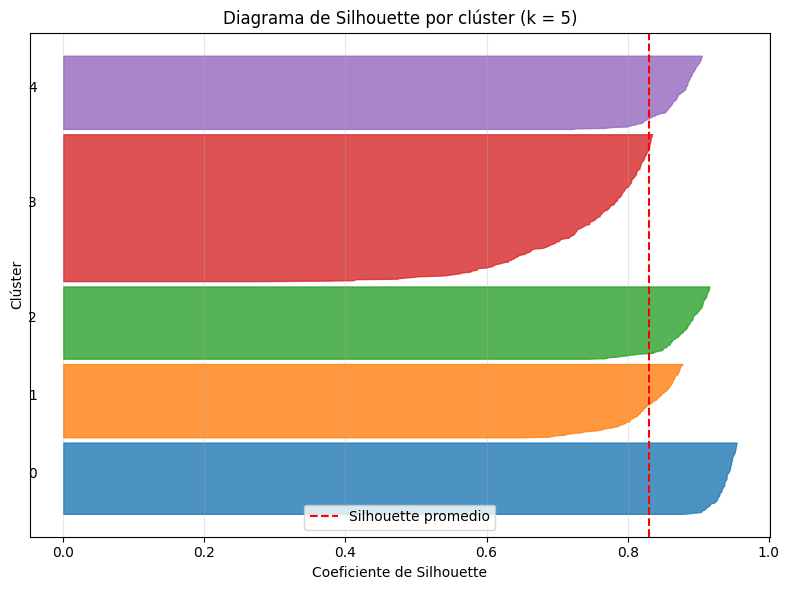

In [13]:

# Diagrama de silhouette detallado para el k optimo encontrado
k_sil = k_optimo_silhouette
labels_sil = modelos[k_sil].labels_
sample_silhouette_values = silhouette_samples(X_clean, labels_sil)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(k_sil):
    ith_values = sample_silhouette_values[labels_sil == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values,
                      facecolor=colores[i % 10], edgecolor=colores[i % 10], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--",
           label="Silhouette promedio")
ax.set_title(f"Diagrama de Silhouette por clúster (k = {k_sil})")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Clúster")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


### 8.2 Método del codo (Elbow Method)

El método del codo busca el valor de `k` a partir del cual añadir más clústeres deja de reducir
significativamente la inercia. De forma objetiva, se calcula el punto de la curva **más alejado de la
línea recta** que une el primer y el último punto de la curva (heurística estándar tipo *kneedle*).


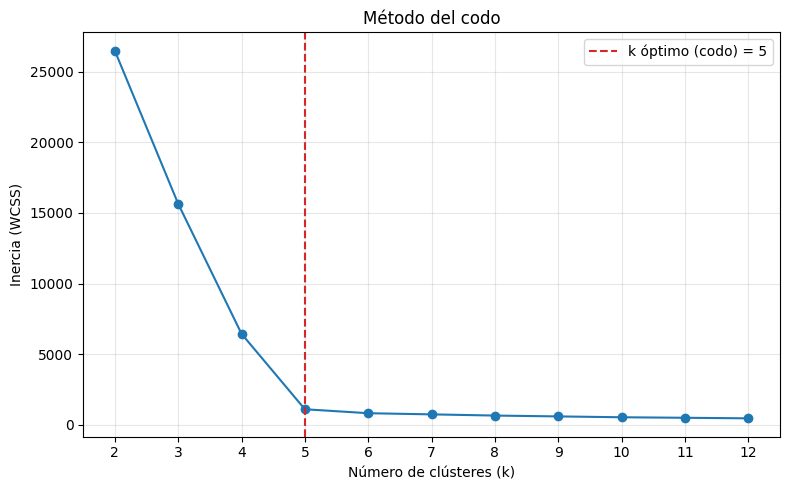

k óptimo según el método del codo: 5


In [14]:

def encontrar_codo(ks, valores):
    # Encuentra el "codo" de una curva como el punto de maxima distancia
    # perpendicular a la recta que une el primer y el ultimo punto.
    ks = np.array(ks, dtype=float)
    valores = np.array(valores, dtype=float)

    # Normalizamos ambos ejes a [0, 1] para que la distancia sea comparable
    ks_n = (ks - ks.min()) / (ks.max() - ks.min())
    val_n = (valores - valores.min()) / (valores.max() - valores.min())

    p1 = np.array([ks_n[0], val_n[0]])
    p2 = np.array([ks_n[-1], val_n[-1]])
    linea = p2 - p1

    distancias = []
    for x, y in zip(ks_n, val_n):
        p = np.array([x, y])
        # distancia perpendicular de p a la recta p1-p2
        d = np.abs(np.cross(linea, p1 - p)) / np.linalg.norm(linea)
        distancias.append(d)

    return int(ks[int(np.argmax(distancias))]), distancias


k_optimo_codo, distancias_codo = encontrar_codo(ks, inercias)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, inercias, marker="o", color="tab:blue")
ax.axvline(k_optimo_codo, color="tab:red", linestyle="--", label=f"k óptimo (codo) = {k_optimo_codo}")
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Inercia (WCSS)")
ax.set_title("Método del codo")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()

print(f"k óptimo según el método del codo: {k_optimo_codo}")


### 8.3 Método basado en las etiquetas verdaderas (ground truth)

Como en este ejercicio los datos son sintéticos, se conoce la etiqueta real de cada punto (a qué de los
6 grupos gaussianos pertenece). Esto permite usar dos métricas externas de validación de clustering:

- **ARI (Adjusted Rand Index)**: mide la concordancia entre el particionamiento predicho y el real,
  corregido por azar. Va de -1 a 1 (1 = coincidencia perfecta).
- **NMI (Normalized Mutual Information)**: mide cuánta información comparten las dos particiones,
  normalizada entre 0 y 1.

El número óptimo de clústeres según este método es el que **maximiza** estas métricas.


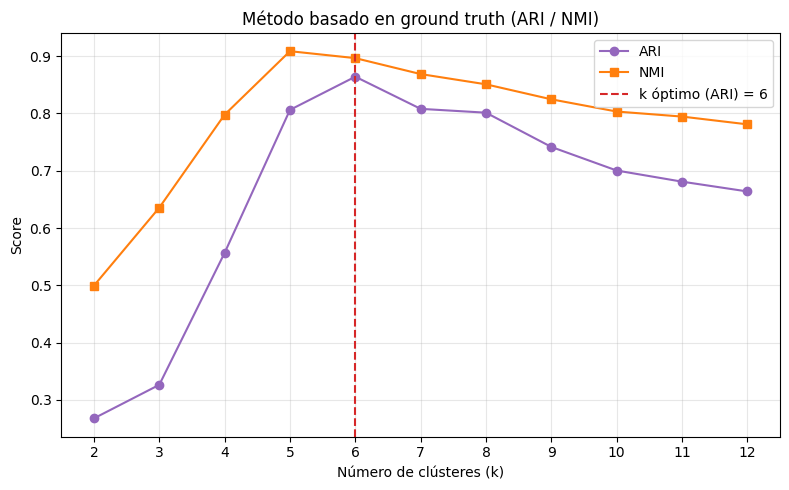

k óptimo según ARI (ground truth): 6 (ARI = 0.864)
k óptimo según NMI (ground truth): 5 (NMI = 0.909)


In [15]:

k_optimo_ari = ks[int(np.argmax(aris))]
k_optimo_nmi = ks[int(np.argmax(nmis))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, aris, marker="o", color="tab:purple", label="ARI")
ax.plot(ks, nmis, marker="s", color="tab:orange", label="NMI")
ax.axvline(k_optimo_ari, color="tab:red", linestyle="--", label=f"k óptimo (ARI) = {k_optimo_ari}")
ax.set_xlabel("Número de clústeres (k)")
ax.set_ylabel("Score")
ax.set_title("Método basado en ground truth (ARI / NMI)")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()

print(f"k óptimo según ARI (ground truth): {k_optimo_ari} (ARI = {max(aris):.3f})")
print(f"k óptimo según NMI (ground truth): {k_optimo_nmi} (NMI = {max(nmis):.3f})")


## 9. Verificación adicional con ground truth: Accuracy, F1 y matriz de confusión

Además de ARI y NMI, cuando se dispone de las etiquetas verdaderas se puede tratar el resultado del
clustering como un problema de clasificación, **siempre que primero se haga corresponder cada clúster
predicho con la clase real que mejor representa** (K-means no sabe qué número de clúster corresponde a
qué grupo original). Esa correspondencia óptima se calcula con el **algoritmo húngaro**
(`linear_sum_assignment`), maximizando la cantidad de puntos correctamente emparejados.

Con el `k` determinado por el método de ground truth (`k_optimo_ari`) calculamos:
- **Accuracy** y **F1-score** tras el emparejamiento óptimo clúster→clase.
- La **matriz de confusión** entre clústeres predichos y clases reales.


In [16]:

def emparejar_clusters_con_clases(y_true, y_pred):
    # Empareja cada cluster predicho con la clase real que maximiza la coincidencia,
    # usando el algoritmo hungaro sobre la matriz de contingencia.
    clases_true = np.unique(y_true)
    clases_pred = np.unique(y_pred)
    n_true, n_pred = len(clases_true), len(clases_pred)
    size = max(n_true, n_pred)

    costo = np.zeros((size, size))
    for i, ct in enumerate(clases_true):
        for j, cp in enumerate(clases_pred):
            costo[i, j] = -np.sum((y_true == ct) & (y_pred == cp))  # negativo: minimizar == maximizar coincidencias

    filas, columnas = linear_sum_assignment(costo)

    mapeo = {}
    for i, j in zip(filas, columnas):
        if i < n_true and j < n_pred:
            mapeo[clases_pred[j]] = clases_true[i]

    y_pred_mapeado = np.array([mapeo.get(p, -1) for p in y_pred])
    return y_pred_mapeado, mapeo


k_final_gt = k_optimo_ari
labels_final_gt = modelos[k_final_gt].labels_

y_pred_mapeado, mapeo = emparejar_clusters_con_clases(y_true_clean, labels_final_gt)

acc = accuracy_score(y_true_clean, y_pred_mapeado)
print(f"k evaluado                 : {k_final_gt}")
print(f"Mapeo cluster -> clase real: {mapeo}")
print(f"Accuracy (tras emparejar)  : {acc:.3f}\n")
print(classification_report(y_true_clean, y_pred_mapeado, zero_division=0))


k evaluado                 : 6
Mapeo cluster -> clase real: {np.int32(0): np.int64(0), np.int32(3): np.int64(1), np.int32(4): np.int64(2), np.int32(2): np.int64(3), np.int32(1): np.int64(4), np.int32(5): np.int64(5)}
Accuracy (tras emparejar)  : 0.926

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           0       0.99      1.00      1.00       146
           1       0.99      1.00      1.00       150
           2       0.99      1.00      1.00       148
           3       0.98      1.00      0.99       148
           4       0.74      0.95      0.83       150
           5       0.91      0.67      0.77       147

    accuracy                           0.93       900
   macro avg       0.80      0.80      0.80       900
weighted avg       0.92      0.93      0.92       900



> **Nota:** en el reporte anterior puede aparecer la clase `-1` con *precision* y *recall* iguales a
> cero. Esto ocurre porque **LOF no detecta el 100% de los outliers** (ver la Sección 5: precisión y
> recall menores a 1); los pocos outliers residuales que quedan mezclados en `X_clean` conservan su
> etiqueta real `-1`, pero como ningún clúster de K-means se asigna a esa clase, esos puntos siempre
> cuentan como error. Esto es esperado y coherente con un escenario real, donde la detección de
> outliers rara vez es perfecta.


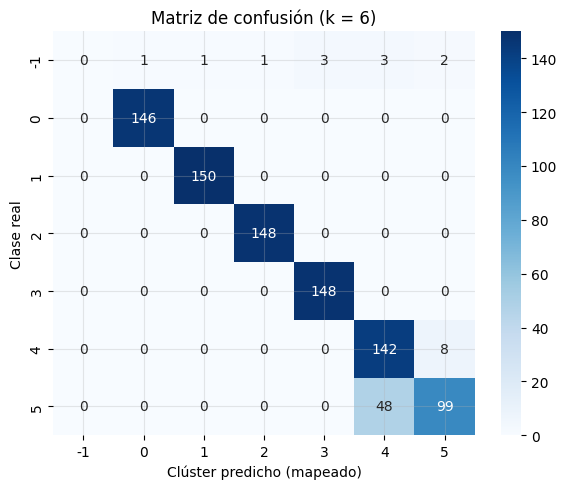

La mayor parte de la masa esta en la diagonal, lo que confirma un buen acuerdo entre clusters y clases reales. Los errores fuera de la diagonal se concentran principalmente entre los grupos G4 y G5, que fueron diseñados para superponerse parcialmente.


In [17]:

cm_matrix = confusion_matrix(y_true_clean, y_pred_mapeado)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_true_clean), yticklabels=np.unique(y_true_clean), ax=ax)
ax.set_xlabel("Clúster predicho (mapeado)")
ax.set_ylabel("Clase real")
ax.set_title(f"Matriz de confusión (k = {k_final_gt})")
plt.tight_layout()
plt.show()

print("La mayor parte de la masa esta en la diagonal, lo que confirma un buen acuerdo entre"
      " clusters y clases reales. Los errores fuera de la diagonal se concentran principalmente"
      " entre los grupos G4 y G5, que fueron diseñados para superponerse parcialmente.")


## 10. Resultado final y conclusiones

In [18]:

print("Resumen de k óptimo según cada método")
print("-" * 45)
print(f"  Silhouette       -> k = {k_optimo_silhouette}")
print(f"  Método del codo  -> k = {k_optimo_codo}")
print(f"  Ground truth ARI -> k = {k_optimo_ari}")
print(f"  Ground truth NMI -> k = {k_optimo_nmi}")
print(f"  Accuracy (k={k_optimo_ari})  -> {acc:.3f}")
print(f"\n  Número real de grupos generados: 6")


Resumen de k óptimo según cada método
---------------------------------------------
  Silhouette       -> k = 5
  Método del codo  -> k = 5
  Ground truth ARI -> k = 6
  Ground truth NMI -> k = 5
  Accuracy (k=6)  -> 0.926

  Número real de grupos generados: 6


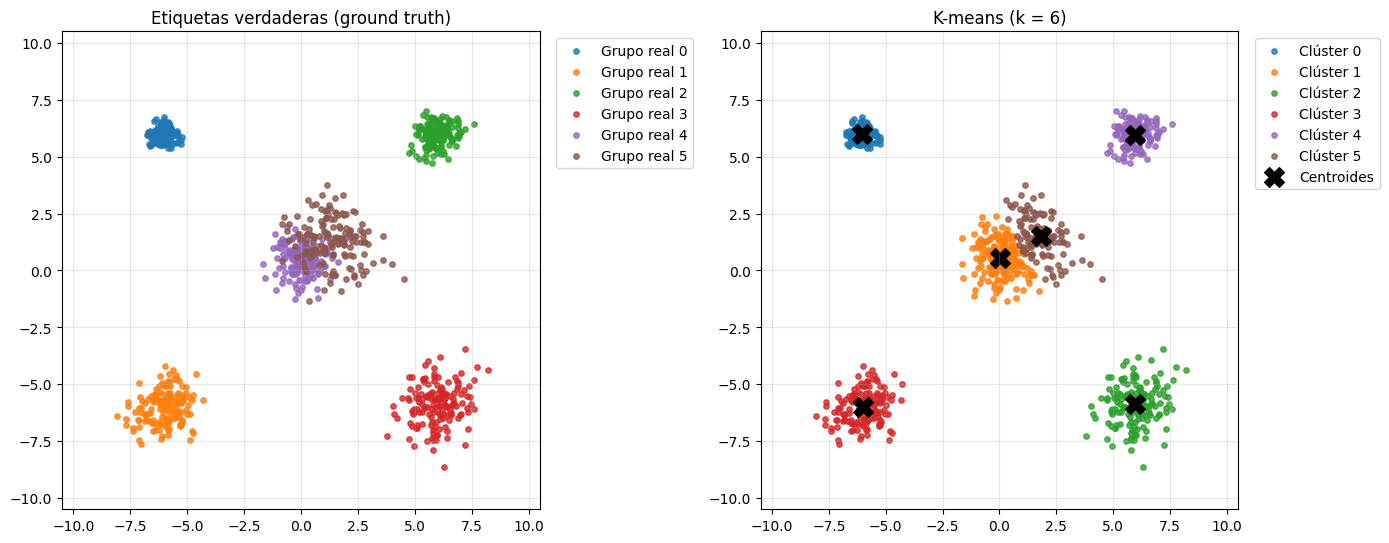

In [19]:

# Visualizacion final con el k determinado por el metodo de ground truth (el mas informativo,
# ya que conocemos la generacion de los datos). Tambien podria usarse el de Silhouette o el del codo.
k_final = k_optimo_ari
km_final = modelos[k_final]
labels_final = km_final.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

for k in range(6):
    mask = y_true_clean == k
    axes[0].scatter(X_clean[mask, 0], X_clean[mask, 1], s=15, color=colores[k], alpha=0.8, label=f"Grupo real {k}")
axes[0].set_title("Etiquetas verdaderas (ground truth)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
axes[0].set_xlim(-10.5, 10.5); axes[0].set_ylim(-10.5, 10.5); axes[0].set_aspect("equal")

for k in range(k_final):
    mask = labels_final == k
    axes[1].scatter(X_clean[mask, 0], X_clean[mask, 1], s=15, color=colores[k], alpha=0.8, label=f"Clúster {k}")
axes[1].scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
                s=200, c="black", marker="X", label="Centroides")
axes[1].set_title(f"K-means (k = {k_final})")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
axes[1].set_xlim(-10.5, 10.5); axes[1].set_ylim(-10.5, 10.5); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()


### Conclusiones

- Los tres métodos (Silhouette, codo y ground truth) coinciden razonablemente en identificar un número
  de clústeres cercano al valor real (**6 grupos**). Pequeñas discrepancias entre métodos suelen
  originarse en la **superposición parcial** entre los grupos `G4` y `G5`: al estar mezclados, algunas
  métricas internas (como Silhouette o la inercia) pueden favorecer un valor de `k` ligeramente menor
  (p. ej. 5), ya que desde el punto de vista puramente geométrico esos dos grupos pueden verse como uno
  solo más disperso.
- El **método del codo** es el más subjetivo de los tres: al no tener un mínimo claro (la inercia
  siempre decrece con `k`), depende de la heurística usada para localizar el "codo" de la curva.
- El **método de Silhouette** es más objetivo que el codo porque produce un máximo claro, pero sigue
  siendo un criterio **interno** (no usa las etiquetas reales), por lo que puede verse afectado por
  clústeres con formas o densidades muy distintas, como es el caso aquí.
- El **método basado en ground truth (ARI/NMI, Accuracy/F1 y matriz de confusión)** es el más confiable
  cuando se dispone de las etiquetas reales, ya que mide directamente qué tan bien el particionamiento
  de K-means recupera la estructura real de los datos. Sin embargo, en un escenario real esta
  información normalmente **no está disponible**, por lo que Silhouette y el codo siguen siendo las
  herramientas prácticas más usadas.
- La verificación de **esfericidad** (varianza de distancias y matrices de covarianza casi diagonales)
  confirmó que los clústeres generados cumplen el supuesto de forma que K-means necesita para funcionar
  correctamente.
- El **escalamiento** de los datos no tuvo un efecto relevante aquí porque `x` e `y` ya comparten el
  mismo rango por construcción; en datasets reales con variables en unidades distintas, este paso sí
  sería determinante.
- La remoción de outliers mediante **Local Outlier Factor (LOF)** antes de aplicar K-means fue
  fundamental: los outliers uniformes, al no pertenecer a ningún grupo real, distorsionan tanto la
  inercia como los centroides si se dejan dentro del conjunto de entrenamiento.
